# 01 — Data Cleaning & Integration (Deliverable A)

This notebook explores the raw tables, runs the cleaning pipeline in `src/cleaning.py`, and documents A1–A8.

**Clock convention:** all joined timestamps are `Africa/Addis_Ababa` (EAT, UTC+3).

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.cleaning import (
    build_master_tables,
    export_outputs,
    integrity_checks,
    CANONICAL_ZONES,
    parse_mixed_timestamps,
    parse_weather_timestamps,
    normalize_zones_series,
)

RAW = ROOT / 'data' / 'raw'
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

## Exploratory look at raw files

In [2]:
train_raw = pd.read_csv(RAW / 'ride_demand_train.csv')
test_raw = pd.read_csv(RAW / 'ride_demand_test.csv')
weather_raw = pd.read_csv(RAW / 'weather_hourly.csv')
events_raw = pd.read_csv(RAW / 'events_calendar.csv')

for name, df in [('train', train_raw), ('test', test_raw), ('weather', weather_raw), ('events', events_raw)]:
    print(f'=== {name}: {df.shape} ===')
    print(df.dtypes)
    print('nulls:', df.isna().sum().to_dict())
    print()

=== train: (85460, 7) ===
record_id             str
zone                  str
pickup_hour           str
trips             float64
avg_fare_birr     float64
avg_wait_min      float64
active_drivers      int64
dtype: object
nulls: {'record_id': 0, 'zone': 0, 'pickup_hour': 0, 'trips': 845, 'avg_fare_birr': 1277, 'avg_wait_min': 0, 'active_drivers': 0}

=== test: (4032, 3) ===
row_id         str
zone           str
pickup_hour    str
dtype: object
nulls: {'row_id': 0, 'zone': 0, 'pickup_hour': 0}

=== weather: (7538, 6) ===
timestamp           str
temp_c          float64
rain_mm         float64
humidity_pct    float64
wind_kmh        float64
data_type           str
dtype: object
nulls: {'timestamp': 0, 'temp_c': 42, 'rain_mm': 0, 'humidity_pct': 153, 'wind_kmh': 0, 'data_type': 0}

=== events: (165, 9) ===
event_id               str
event_name             str
event_type             str
venue                  str
zone                   str
start_datetime         str
end_datetime           s

In [3]:
print('Raw zone labels (train):', train_raw['zone'].nunique())
print(sorted(train_raw['zone'].unique())[:25], '...')
print('\nSample pickup_hour formats:')
print(train_raw['pickup_hour'].head(10).tolist())
print('\nWeather timestamp samples:')
print(weather_raw['timestamp'].head(3).tolist(), weather_raw['timestamp'].tail(3).tolist())
print('\ntrips describe:')
print(train_raw['trips'].describe())

Raw zone labels (train): 55
['ARAT KILO', 'AYAT', 'Arat  Kilo', 'Arat Kilo', 'Arat Kilo ', 'Ayat', 'Ayat ', 'BOLE', 'Bole', 'Bole ', 'Bole Rd', 'C.M.C', 'CMC', 'CMC ', 'GERJI', 'Gerji', 'Gerji ', 'KAZANCHIS', 'KOLFE', 'Kazanches', 'Kazanchis', 'Kazanchis ', 'Kolfe', 'Kolfe ', 'Kolfe Keranio'] ...

Sample pickup_hour formats:
['2025-06-26 11:00', '16/08/2025 04:00', '2025-10-17 11:00', '2025-01-09 18:00', '2025-05-24 03:00', '24/02/2025 14:00', '2025-05-27T23:00:00+03:00', '2025-03-19 10:00', '2025-03-08 07:00', '18/07/2025 03:00']

Weather timestamp samples:
['2024-12-30T21:00:00Z', '2024-12-30T22:00:00Z', '2024-12-30T23:00:00Z'] ['2025-11-14T18:00:00Z', '14/11/2025 19:00', '2025-11-14T20:00:00Z']

trips describe:
count    84615.000000
mean        28.518466
std         25.787560
min         -1.000000
25%          9.000000
50%         23.000000
75%         41.000000
max        640.000000
Name: trips, dtype: float64


## A2 — Time & key standardization (timezone proof)

Trip rows with explicit offsets use `+03:00` (EAT). Weather rows mostly end in `Z` (UTC).
If we join without converting, rain would be shifted ~3 hours relative to demand.

Fraction weather timestamps ending in Z (UTC): 0.903
Fraction train pickup_hour with +03:00: 0.150


Hour (EAT) of mean temp peak: 15 C= 24.6


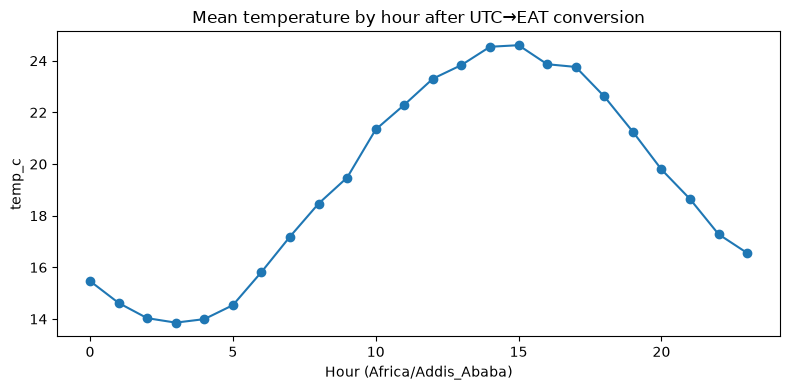

In [4]:
# Evidence: weather Z timestamps vs trip +03:00
w_z = weather_raw['timestamp'].astype(str).str.endswith('Z').mean()
t_eat = train_raw['pickup_hour'].astype(str).str.contains(r'\+03:00', regex=True).mean()
print(f'Fraction weather timestamps ending in Z (UTC): {w_z:.3f}')
print(f'Fraction train pickup_hour with +03:00: {t_eat:.3f}')

w_parsed_utc_as_eat = parse_weather_timestamps(weather_raw['timestamp'])
tmp = weather_raw.copy()
tmp['ts_eat'] = w_parsed_utc_as_eat
tmp['hour_eat'] = tmp['ts_eat'].dt.hour
# Temperature should peak mid-afternoon local time (~14-16 EAT), not morning
curve = tmp.groupby('hour_eat')['temp_c'].mean()
print('Hour (EAT) of mean temp peak:', int(curve.idxmax()), 'C=', round(curve.max(), 2))

fig, ax = plt.subplots(figsize=(8, 4))
curve.plot(ax=ax, marker='o')
ax.set_title('Mean temperature by hour after UTC→EAT conversion')
ax.set_xlabel('Hour (Africa/Addis_Ababa)')
ax.set_ylabel('temp_c')
plt.tight_layout()
plt.show()

In [5]:
print('Zones BEFORE cleaning (train nunique):', train_raw['zone'].nunique())
print('Zones AFTER normalize map:', normalize_zones_series(train_raw['zone']).nunique())
print('Canonical target list:', CANONICAL_ZONES)

Zones BEFORE cleaning (train nunique): 55


Zones AFTER normalize map: 12
Canonical target list: ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']


## A1 / A3 / A4 / A5 / A6 / A7 / A8 — Run full pipeline

In [6]:
bundle = build_master_tables()
export_outputs(bundle)

print('Cleaning log (A1):')
display(bundle['cleaning_log'])

print('Weather join audit (A4):', bundle['weather_audit'])
print('Events join audit (A4):', bundle['events_audit'])
print('Zones after:', bundle['zone_after'])

C:\xampp\htdocs\ride_forcasting\src\cleaning.py:241: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(s[mon_mask], errors="coerce")
C:\xampp\htdocs\ride_forcasting\src\cleaning.py:241: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(s[mon_mask], errors="coerce")


Cleaning log (A1):


,file,columns,issue_type,n_affected,pct_affected,fix,why
0,ride_demand_train.csv,zone,inconsistent_spelling,55,0.06,Mapped 55 raw labels -> 12 canonical zones; un...,Joins and models need one label per zone
1,ride_demand_train.csv,pickup_hour,mixed_datetime_formats,85460,100.00,"Parsed ISO+03, YYYY-MM-DD HH:MM, DD/MM/YYYY HH...",Mixed formats cause silent day/month swaps if ...
2,ride_demand_train.csv,trips,impossible_negative,681,0.80,Set trips<0 to NaN,Trip counts cannot be negative
3,ride_demand_train.csv,trips,missing_target,1526,1.79,Kept as NaN for analysis; dropped only when fi...,Missing targets should not be silently filled ...
4,ride_demand_train.csv,trips,extreme_outlier,81,0.09,Capped trips at 99.9th pct (192.0); kept trips...,A few extreme spikes distort RMSE and tree splits
5,ride_demand_train.csv,avg_wait_min,impossible_negative,1707,2.00,Set avg_wait_min<0 to NaN,Wait time cannot be negative
6,ride_demand_train.csv,avg_fare_birr,missing_values,1277,1.49,Left as NaN (analysis only; not a forecast-tim...,Operational column — useful for EDA/demo fares...
7,ride_demand_train.csv,"zone,pickup_hour",duplicate_zone_hour,846,0.99,Kept first row per zone-hour,Many-to-one weather join requires unique left ...
8,ride_demand_test.csv,zone,inconsistent_spelling,55,1.36,Mapped 55 raw labels -> 12 canonical zones; un...,Joins and models need one label per zone
9,ride_demand_test.csv,pickup_hour,mixed_datetime_formats,4032,100.00,"Parsed ISO+03, YYYY-MM-DD HH:MM, DD/MM/YYYY HH...",Mixed formats cause silent day/month swaps if ...


Weather join audit (A4): {'left_rows_before': 88646, 'rows_after': 88646, 'match_rate': 1.0, 'zone_hours_without_weather': 0, 'join_type': 'left many-to-one on pickup_hour'}
Events join audit (A4): {'events_total': 165, 'confirmed_event_rows': 159, 'cancelled_event_rows': 6, 'events_matched_at_least_one_zone_hour': 159, 'events_excluded_or_unmatched': 0, 'trip_rows_in_any_event_window': 24155, 'window_rule': 'type-specific [start-pre, end+post]; football/concert pre=2h post=2h; confirmed only'}
Zones after: {'train': ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet'], 'test': ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet'], 'events': ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']}


### A3 — Join map (text diagram)

```
ride_demand_*  (left, grain = zone × hour)
      |
      | many-to-one on pickup_hour == weather.timestamp (EAT)
      v
weather_hourly (unique hour after dedupe)
      |
      | interval join on zone + hour ∈ [event.start-pre, event.end+post]
      v
events_calendar (confirmed only; citywide expanded to 12 zones)
      |
      v
master_train / master_test + engineered features
```

**Why trips are left:** we must keep every zone-hour we need to score; weather/events enrich them.
**Event window:** football/concert ±2h; holidays exact day; confirmed status only.

### A5 — Join proof (3 zone-hours)

In [7]:
mt = bundle['master_train']

rain_ex = mt[mt['rain_mm'] > 2].sort_values('rain_mm', ascending=False).head(1)
event_ex = mt[mt['is_football_window'] == 1].head(1)
hol_ex = mt[mt['is_public_holiday'] == 1].head(1)

for label, ex in [('rain', rain_ex), ('football', event_ex), ('holiday', hol_ex)]:
    print('---', label, '---')
    cols = ['zone', 'pickup_hour', 'trips', 'temp_c', 'rain_mm', 'in_event_window',
            'is_football_window', 'is_public_holiday', 'event_attendance_nearby', 'rain_class']
    display(ex[cols])

--- rain ---


,zone,pickup_hour,trips,temp_c,rain_mm,in_event_window,is_football_window,is_public_holiday,event_attendance_nearby,rain_class
80317,Sarbet,2025-05-02 17:00:00,39.0,21.5,21.0,0,0,0,0.0,heavy


--- football ---


,zone,pickup_hour,trips,temp_c,rain_mm,in_event_window,is_football_window,is_public_holiday,event_attendance_nearby,rain_class
34694,Kazanchis,2025-01-19 13:00:00,36.0,22.2,0.0,1,1,1,16007.0,none


--- holiday ---


,zone,pickup_hour,trips,temp_c,rain_mm,in_event_window,is_football_window,is_public_holiday,event_attendance_nearby,rain_class
143,Arat Kilo,2025-01-07,4.0,8.7,0.0,1,0,1,0.0,none


### A6 — Feature engineering table

In [8]:
display(bundle['data_dictionary'])
print('Model features (' + str(len(bundle['model_features'])) + '):')
print(bundle['model_features'])

,column,type,source,description,derived_how,known_at_forecast_time,why_expect_help
0,row_id,id,test/submission,Row id,pass-through,n/a,Submission key only
1,record_id,id,train,Record id,pass-through,n/a,Train row key only
2,zone,categorical,trips,Canonical pickup zone,alias map,yes,Demand level differs sharply by neighborhood
3,pickup_hour,datetime,trips,Hour start in EAT,parsed/floored,yes,Time key for joins and calendar features
4,trips,target,trips,Trips in zone-hour,cleaned/capped,n/a (target),Prediction target
5,hour,int,calendar,Hour of day 0-23,pickup_hour.dt.hour,yes,Strong diurnal peaks (commute / nightlife)
6,dow,int,calendar,Day of week Mon=0,pickup_hour.dt.dayofweek,yes,Weekday vs weekend demand shapes differ
7,is_weekend,int,calendar,Sat/Sun flag,dow>=5,yes,Weekend leisure vs weekday commute split
8,month,int,calendar,Month number,pickup_hour.dt.month,yes,Captures seasonal level shifts
9,is_payday_window,int,calendar,Payday proximity flag,day<=3 or last 3 days,yes,Pay cycles often lift short trips


Model features (25):
['zone', 'hour', 'dow', 'is_weekend', 'month', 'is_payday_window', 'week_index', 'temp_c', 'rain_mm', 'humidity_pct', 'wind_kmh', 'rain_class', 'rain_last_3h', 'in_event_window', 'is_public_holiday', 'is_football_window', 'is_concert_window', 'is_road_closure', 'hours_to_next_football', 'hours_since_football', 'event_attendance_nearby', 'n_events_overlapping', 'trips_lag_168h', 'trips_roll_mean_24h', 'trips_roll_mean_168h']


### A7 — Integrity checks

In [9]:
checks = integrity_checks(bundle['master_train'], bundle['master_test'])
for name, ok, detail in checks:
    print(('PASS' if ok else 'FAIL') + f': {name} — {detail}')
assert all(ok for _, ok, _ in checks), 'Some integrity checks failed'

PASS: train_unique_zone_hour — dupes=0


PASS: test_unique_zone_hour — dupes=0
PASS: zones_are_canonical — train=['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']
PASS: timestamps_in_range_train — 2025-01-01 00:00:00 .. 2025-10-31 23:00:00
PASS: timestamps_in_range_test — 2025-11-01 00:00:00 .. 2025-11-14 23:00:00
PASS: no_negative_trips_left — min=0.0
PASS: weather_columns_complete — all weather features non-null on train
PASS: same_model_feature_columns — model feature list present on train and test
PASS: leaky_ops_not_in_model_features — model_features overlap leaky=set()
PASS: test_row_count_4032 — len=4032


### A8 — Master exports

Written to `data/processed/`:
- `master_train.csv`
- `master_test.csv`
- `data_dictionary_master.csv`
- `cleaning_log.csv`

In [10]:
print(bundle['master_train'].shape, bundle['master_test'].shape)
bundle['master_train'].head()

(84614, 37) (4032, 37)


,active_drivers,avg_fare_birr,avg_wait_min,pickup_hour,record_id,row_id,trips,trips_raw,zone,zone_raw,temp_c,rain_mm,humidity_pct,wind_kmh,data_type,in_event_window,is_public_holiday,is_football_window,is_concert_window,is_road_closure,hours_to_next_football,hours_since_football,event_attendance_nearby,n_events_overlapping,event_names,hour,dow,is_weekend,month,day,is_payday_window,week_index,rain_class,rain_last_3h,trips_lag_168h,trips_roll_mean_24h,trips_roll_mean_168h
0,5.0,240.4,1.9,2025-01-01 00:00:00,R-070502,R-070502,5.0,5.0,Arat Kilo,Arat Kilo,8.70,0.0,87.5,11.20,observed,0,0,0,0,0,168.0,168.0,0.0,0,,0,2,0,1,1,1,0,none,0.0,15.0,21.50,20.073171
1,3.0,224.4,1.2,2025-01-01 01:00:00,R-045764,R-045764,2.0,2.0,Arat Kilo,Arat Kilo,8.00,0.0,87.0,13.60,observed,0,0,0,0,0,168.0,168.0,0.0,0,,1,2,0,1,1,1,0,none,0.0,15.0,5.00,5.000000
2,3.0,226.5,1.2,2025-01-01 02:00:00,R-023866,R-023866,2.0,2.0,Arat Kilo,Arat Kilo,7.20,0.0,100.0,9.00,observed,0,0,0,0,0,168.0,168.0,0.0,0,,2,2,0,1,1,1,0,none,0.0,15.0,3.50,3.500000
3,5.0,233.1,1.3,2025-01-01 03:00:00,R-024252,R-024252,4.0,4.0,Arat Kilo,Arat Kilo,6.95,0.0,96.0,10.45,imputed_gap,0,0,0,0,0,168.0,168.0,0.0,0,,3,2,0,1,1,1,0,none,0.0,15.0,3.00,3.000000
4,6.0,244.2,1.2,2025-01-01 04:00:00,R-005550,R-005550,5.0,5.0,Arat Kilo,Arat Kilo,6.70,0.0,92.0,11.90,observed,0,0,0,0,0,168.0,168.0,0.0,0,,4,2,0,1,1,1,0,none,0.0,15.0,3.25,3.250000


## Quick EDA on cleaned demand (feeds Deliverable B)

Zone share of city trips:
zone
Merkato      12.0
Bole         11.7
Megenagna    11.4
Kazanchis     9.5
Piassa        8.4
Lideta        8.4
CMC           7.7
Gerji         7.2
Kolfe         6.9
Sarbet        6.5
Arat Kilo     6.1
Ayat          4.1
Name: trips, dtype: float64


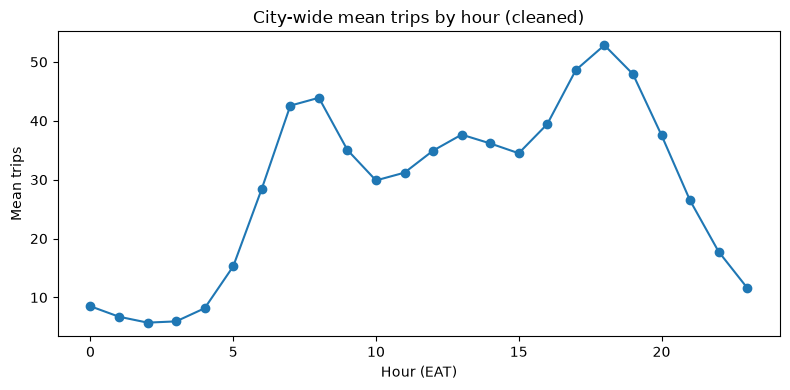

In [11]:
clean = bundle['master_train'].dropna(subset=['trips'])
zone_share = clean.groupby('zone')['trips'].sum().sort_values(ascending=False)
zone_share = zone_share / zone_share.sum()
print('Zone share of city trips:')
print((zone_share * 100).round(1))

hourly = clean.groupby('hour')['trips'].mean()
fig, ax = plt.subplots(figsize=(8, 4))
hourly.plot(ax=ax, marker='o')
ax.set_title('City-wide mean trips by hour (cleaned)')
ax.set_xlabel('Hour (EAT)')
ax.set_ylabel('Mean trips')
plt.tight_layout()
plt.show()